# Assignment 2 [78 pts]
The objective for this assignment is to apply:
* Linear regression
* Evaluate model performance using different methods
* Tunning parameters
* Use L1-L2 regularization
* Gradient descendet and sochastic gradient descendent

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns

## PART 1. INTERPRETATION [24 pts]

For this part, we will use the Linear Regression from statmodels class https://www.statsmodels.org/stable/regression.html

In [2]:
import statsmodels.api as sm

### Data Description:
Forced expiratory volume (FEV) is an index of pulmonary function that measures the volume of air expelled after one second of constant effort. The data set contains FEV determinations of 654 children seen in the Childhood Respiratory Disease Study, which aimed to detect factors related to pulmonary function in children. The data set comprises the following variables:

* Age: Subject Age (in years)
* FEV: Forced Expiratory Volume (liters)
* Height: Subject Height (inches)
* Sex: Subject Gender, 0 = female / 1 = male
* Smoke: Subject Smoking Status, 0= not a current smoker / 1 = current smoker

First, let's load the data.

In [3]:
fev = pd.read_csv("./fev.csv")
# Printing head
fev.head()

,age,height,sex,smoke,fev
0,9,57.0,0,0,1.708
1,8,67.5,0,0,1.724
2,7,54.5,0,0,1.720
3,9,53.0,1,0,1.558
4,9,57.0,1,0,1.895


For our regression, `fev` is our response variable, and the remaining variables are the independent variables (or predictors)

In [4]:
varNames = fev.columns[:-1]
responseVar = fev.columns[-1]

**[6 pts]** Fit a regression model using OLS from the `statsmodels.api`. Remember that to use linear regression, we need to attach a column of ones to the features. In statmodels, we can do that using `sm.add_constant`. 

In [5]:
# TO DO
X_with_const = sm.add_constant(fev[varNames])
model = sm.OLS(fev[responseVar], X_with_const)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    fev   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     560.0
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          9.10e-209
Time:                        18:57:41   Log-Likelihood:                -345.90
No. Observations:                 654   AIC:                             701.8
Df Residuals:                     649   BIC:                             724.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4570      0.223    -20.001      0.0

**[5 pts]** Based on the report provided by the OLS model, answer the following questions.

1. Is there a relationship between the predictors and the response?
2. How strong is the relationship between the predictors and the response?
3. Which predictors appear to have a statistically significant relationship to the response?
4. Are boys or girls more likely to have higher FEV? Why? 

1. Yes there is a relationship between the predictors and response
2. The relationship is strong because the R-squared value is 0.775, which means 77.5% of the variance in the response variable can be explained by the predictors.
3. Since the p values of age, height, and sex are less than 0.05, we can say these predictors have significant effects.
4. Boys are 15.7% more likely to have a higher FEV than girls. This is because of the coefficient value of sex, which is 0.157.

## Colliniarity among variable

In statistics, correlation or dependence is any statistical relationship, whether causal or not, between two random variables or bivariate data. Although in the broadest sense, "correlation" may indicate any type of association, in statistics it usually refers to the degree to which a pair of variables are linearly related. [Correlation Wikipedia Page](https://en.wikipedia.org/wiki/Correlation)

Before fitting our regression model, it is crucial to assess whether the variables are correlated with each other. This is because when two or more predictor variables exhibit strong correlations, it can pose challenges in the regression analysis. In such cases, it becomes difficult to distinguish the individual effects of collinear variables on the response variable.

We can use the .cor() method from pandas for calculating the correlation among the variables.

             age    height       sex     smoke       fev
age     1.000000  0.791944  0.029144  0.404252  0.756459
height  0.791944  1.000000  0.159029  0.280387  0.868135
sex     0.029144  0.159029  1.000000 -0.075612  0.208415
smoke   0.404252  0.280387 -0.075612  1.000000  0.245425
fev     0.756459  0.868135  0.208415  0.245425  1.000000


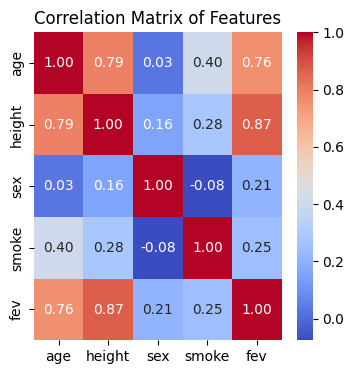

In [7]:
# calculating correlation
correlation_matrix = fev.corr()

print(correlation_matrix)

#visualizing correlation
plt.figure(figsize=(4, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [8]:
#converting correlation dataframe to numpy matrix
correlationMatrix = correlation_matrix.to_numpy()

correlationMatrix_predictor = correlationMatrix[:-1,:-1]
correlationMatrix_response = correlationMatrix[-1,:-1]

print('shape of correlationMatrix_predictor {} and correlationMatrix_response {}'.format(correlationMatrix_predictor.shape, correlationMatrix_response.shape )  )

shape of correlationMatrix_predictor (4, 4) and correlationMatrix_response (4,)


Let's create a function with arguments `correlationMatrix_predictor`, `correlationMatrix_response`, and the variable names. This function will identify variables with a correlation higher than a specified threshold (e.g., 0.5) and retain only the variable that has a higher correlation with the response variable.

In [9]:
def removingCorrelatedVariables( correlationMatrix_predictor,  correlationMatrix_response, varNames, thr=0.5 ):
    selectedVariables = varNames
    

    dropVar = set()

    thr = .5
    for iRow in range( correlationMatrix_predictor.shape[0]-1  ):
        for iCol in range( iRow+1, correlationMatrix_predictor.shape[1]  ):

            if np.abs( correlationMatrix_predictor[ iRow, iCol ] ) > thr:
                if np.abs( correlationMatrix_response [iRow] ) > np.abs( correlationMatrix_response [iCol] ):
                    dropVar.add( varNames[iCol] )
                else:
                    dropVar.add( varNames[iRow] )
    selectedVariables = selectedVariables.drop( list( dropVar) ) 


    return selectedVariables         

selectedVariables = removingCorrelatedVariables( correlationMatrix_predictor,  correlationMatrix_response, varNames )
selectedVariables

Index(['height', 'sex', 'smoke'], dtype='str')

As expected, there is a correlation between age and height in children. Typically, older children tend to be taller than younger ones.

**[4 pts]** Fit again the OLS model, but only using the three selected variables. Compare this model with the first fitted model.

In [10]:
X_selected = sm.add_constant(fev[selectedVariables])
model_selected = sm.OLS(fev[responseVar], X_selected)
results_selected = model_selected.fit()
print(results_selected.summary())

                            OLS Regression Results                            
Dep. Variable:                    fev   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     681.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          3.06e-200
Time:                        18:59:07   Log-Likelihood:                -369.07
No. Observations:                 654   AIC:                             746.1
Df Residuals:                     650   BIC:                             764.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3621      0.187    -28.743      0.0

Provide your answer here:




In comparison to the 1st fitted model, the second model is significantly better. Although the age and height are sort of correlated, removing the age predictor will affect the model more than it helps.

Now, let's try to better understand the effect of smoking. Considering that the children in our study range between 3 and 19 years old, we can reasonably expect that smoking habits are not common among preschoolers and elementary students but rather more associated with teenagers. 

To gain a better perspective, we can print the prevalence of smokers for each age and sex group.

In [11]:
fev.groupby( by=['age','sex'])['smoke'].mean() 

age  sex
3    0      0.000000
     1      0.000000
4    0      0.000000
     1      0.000000
5    0      0.000000
     1      0.000000
6    0      0.000000
     1      0.000000
7    0      0.000000
     1      0.000000
8    0      0.000000
     1      0.000000
9    0      0.000000
     1      0.020000
10   0      0.117647
     1      0.021277
11   0      0.133333
     1      0.066667
12   0      0.137931
     1      0.107143
13   0      0.416667
     1      0.157895
14   0      0.333333
     1      0.250000
15   0      0.700000
     1      0.333333
16   0      0.500000
     1      0.571429
17   0      0.000000
     1      0.285714
18   0      0.000000
     1      0.666667
19   0      1.000000
     1      0.000000
Name: smoke, dtype: float64

Based on the information printed in the previous block, it appears that smoking is more prevalent among children older than 10 years old. So. let's focus on that population.


**[4 pts]** Fit an OLS model using the information on children older than or equal to 10 and using only the variables ['height,' 'sex,' 'smoke']. 

In [12]:
fev_10plus = fev[fev['age'] >= 10]

X_10plus = sm.add_constant(fev_10plus[['height', 'sex', 'smoke']])
y_10plus = fev_10plus['fev']

model_10plus = sm.OLS(y_10plus, X_10plus)
results_10plus = model_10plus.fit()
print(results_10plus.summary())

                            OLS Regression Results                            
Dep. Variable:                    fev   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                     158.4
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.59e-64
Time:                        18:59:44   Log-Likelihood:                -241.99
No. Observations:                 345   AIC:                             492.0
Df Residuals:                     341   BIC:                             507.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.5970      0.504    -13.101      0.0

**[5 pts]** What can we conclude for children ranging from 10 to 19 years old? Does the FEV differ according to either sex or smoking status? Which variable is the predictor of FEV? 

Provide your answer here:

We can conclude that neither sex nor smoking status are significant but have a negative effect on FEV. Since Height has a very low p valueand and a large coefficient, we can say it is the Predictor of FEV.

# PART 2. PREDICTION [54 pts]

For the second part, we will focus more on prediction. For this part, we are going to use the sklearn.linear_model  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [13]:
from sklearn.linear_model import LinearRegression

## Data set

For part 2, we will use a dataset containing 20,640 samples, each representing a geographical region (or neighborhood) in California. For each geographical area, we have its location (longitude and latitude) and the median price of the houses in that area. We also have some features describing the houses, such as the median age, median total rooms, or number of households.

In [14]:
housing = pd.read_csv("./housing.csv")
# Printing head
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Let's use the The info() method is to get a quick description of the data, in particular the total number of rows,
and each attribute’s type and number of non-null values

In [15]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Let’s also use the describe() method t0 show a summary of the numerical attributes


In [16]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


We can observe from the info() that `total_bedrooms` has some nan values. As we cannot use nan values for training our regression, we need to replace that nan value with a value. For this assignment, we will replace the nan values with the median number of bedrooms. 

In [17]:
medianBedrooms = np.nanmedian( housing[ 'total_bedrooms'] ) 

housing.loc[ pd.isna( housing[ 'total_bedrooms' ] ), 'total_bedrooms' ]  = medianBedrooms

print( 'total nan values' , np.sum( pd.isna( housing[ 'total_bedrooms' ] ) ) )

total nan values 0


## Spliting the data
As always, let's split our data into training and test sets. Since these data do not have classes since the response variable is median_income (regression), we do not have any class to use for our stratified splitting. However, because we can expect a relationship between a household's income and the estate price, we want to ensure that we have representative households of the population in both the training and test.

To that aim, let's define a variable named 'income_cat'  by dividing the median income by 1.5 (to limit the number of income categories), rounding up using ceil (to have discrete categories), and then merging all the categories greater than 5 into category 5. These will allow us to categorize the different geographical areas.


In [18]:
#The following code creates an income category attribute by dividing the median income by 1.5 (to limit the number of income categories), and
#rounding up using ceil (to have discrete categories), and then merging all the categories greater than 5
#into category 5:
income_cat = np.ceil(housing["median_income"] / 1.5)
income_cat[ income_cat > 5 ] = 5.0


In [19]:
cols = housing.columns
colRegression = 'median_house_value'
cols = cols.drop( colRegression )
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
for i, (train_index, test_index) in enumerate(sss.split(housing, income_cat )):
    X_train, X_test = housing.iloc[ train_index ][cols], housing.iloc[ test_index ][cols]
    y_train, y_test = housing.iloc[ train_index ][colRegression], housing.iloc[ test_index ][colRegression]
    income_cat_train = income_cat[train_index] 
    income_cat_test = income_cat[test_index]

X_train.reset_index(drop=True, inplace =True )
y_train.reset_index(drop=True, inplace =True )
X_test.reset_index(drop=True, inplace =True )
y_test.reset_index(drop=True, inplace =True )

print('Shape of train set')
print(X_train.shape, y_train.shape )

print('Shape of train set')
print(X_test.shape, y_test.shape  )

Shape of train set
(14448, 9) (14448,)
Shape of train set
(6192, 9) (6192,)


Now, let's visualize what the housing prices look like. We can use the latitude and longitude to plot a scatter plot. To color each circle, we can use the median price. Moreover, we can make the radius of each circle represent the district's population.

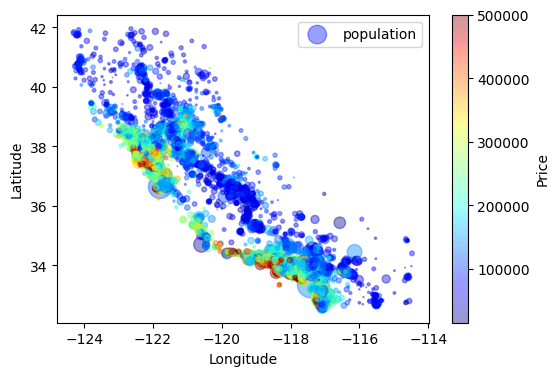

In [20]:
#The radius of each circle represents the district’s population (option s), 
# the color represents the price (option c). 
#We will use a predefined color map (option cmap) called jet, which ranges from blue (low values) to red (high prices):15

plt.figure(figsize=(6, 4))  # Adjust the figure size as needed

# Plotting the scatter plot
scatter = plt.scatter(x=X_train["longitude"], y=X_train["latitude"], alpha=0.4, 
                      s=X_train["population"]/100, label="population", c=y_train, 
                      cmap=plt.get_cmap("jet"))

# Adding colorbar
plt.colorbar(scatter, label='Price')  # Add a color bar with label

# Adding labels and legend
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Display the plot
plt.show()

Interesting....it looks that the closer one gets to the shore, the more expensive the houses become. It seems that, indeed, "Life's a Beach" after all

# Least Square Errors

First, as we did in the first part, let's remove variable that are correlated among them.

In [21]:
varNames = X_train.columns.drop('ocean_proximity')
corr_matrix = X_train[varNames].corr()


correlation_with_y = X_train[varNames].corrwith(y_train)

correlationMatrix_predictor = corr_matrix.to_numpy()
correlationMatrix_response = correlation_with_y.to_numpy()

In [22]:
selectedVariables = removingCorrelatedVariables( correlationMatrix_predictor,  correlationMatrix_response, varNames )
selectedVariables = selectedVariables.tolist() + ['ocean_proximity']

selectedVariables

['latitude',
 'housing_median_age',
 'total_rooms',
 'median_income',
 'ocean_proximity']

We are name the new version of the training and test set as `X_train_filtered` and `X_test_filtered`

In [23]:
X_train_filtered = X_train[selectedVariables]
X_test_filtered = X_test[selectedVariables]

## dummy variables

Before building a regression model, note that the variable 'ocean_proximity' variable is a catgorical variable. That means that we need to convert that variable into dummy variables. To that end, we can use the method pandas.get_dummies()

In [24]:
X_train_filtered['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     6413
INLAND        4549
NEAR OCEAN    1887
NEAR BAY      1596
ISLAND           3
Name: count, dtype: int64

**[5 pts]** Write a function that takes a DataFrame. If the 'ocean_proximity' column is present in the DataFrame, the function creates four dummy variables. We'll designate "<1H OCEAN" as the reference category since it has the most samples (6,406 in total). This implies that when all the dummy variables are set to 0, it represents the "<1H OCEAN" category.

You can modify column values using .loc[condition, col_name] = 1

In [25]:
def getDummies( internal_df ):
    
    if 'ocean_proximity' in internal_df.columns:
        internal_df_dummy = internal_df.copy().drop( 'ocean_proximity', axis=1)

        internal_df_dummy['ISLAND'] = 0
        internal_df_dummy['NEAR BAY'] = 0
        internal_df_dummy['NEAR OCEAN'] = 0
        internal_df_dummy['INLAND'] = 0
        
        # TO DO  ####################################################
        internal_df_dummy.loc[ internal_df['ocean_proximity'] == 'ISLAND', 'ISLAND' ] = 1
        internal_df_dummy.loc[ internal_df['ocean_proximity'] == 'NEAR BAY', 'NEAR BAY' ] = 1
        internal_df_dummy.loc[ internal_df['ocean_proximity'] == 'NEAR OCEAN', 'NEAR OCEAN' ] = 1
        internal_df_dummy.loc[ internal_df['ocean_proximity'] == 'INLAND', 'INLAND' ] = 1
    
    
        ################################################
    else:
        internal_df_dummy = internal_df
        
    return internal_df_dummy

In [26]:
X_train_dummies = getDummies( X_train_filtered )
np.sum(X_train_dummies,axis=0)

latitude              5.146309e+05
housing_median_age    4.125580e+05
total_rooms           3.804404e+07
median_income         5.593172e+04
ISLAND                3.000000e+00
NEAR BAY              1.596000e+03
NEAR OCEAN            1.887000e+03
INLAND                4.549000e+03
dtype: float64

### Measuring the predictive performance.

Now, we will use a 10-Fold Cross-Validation to estimate the error of using the selected features.

**[8 pt]** Complete the below function that performs fold cross-validation. For each iteration, you need to calculate the R2 and MSE. Use the following equations:

$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$

$R2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y} )^2} $

where $\hat{y}_i$ is the prediction and $\bar{y}$ is the mean value for the response variable.

In [27]:
from sklearn.model_selection import StratifiedKFold
def perform_CV(X_train_cv, y_val_cv, cat_for_split, folds ):
    skf = StratifiedKFold(n_splits=folds, random_state= 10, shuffle=True )
    
    mse_kfold = np.empty(  folds ) 
    r2_kfold = np.empty(  folds ) 
    
    for i, (train_index, val_index) in enumerate(skf.split(X_train_cv, income_cat_train )):
        X_train_val, X_val = X_train_cv.iloc[ train_index ], X_train_cv.iloc[ val_index ]
        y_train_val, y_val = y_val_cv.iloc[ train_index ], y_val_cv.iloc[ val_index ]
        
        ##     TO DO ###########################################################
        # complete the function #######################
        model = LinearRegression()
        model.fit(X_train_val, y_train_val)

        y_pred = model.predict(X_val)

        mse_kfold[i] = np.mean( (y_val - y_pred) ** 2)

        ss_res = np.sum((y_val - y_pred) ** 2 )
        ss_tot = np.sum((y_val - np.mean(y_val) ) ** 2 )
        r2_kfold[i] = 1 - (ss_res / ss_tot)
       
        
    return mse_kfold, r2_kfold
    

In [28]:
mse_kfold, r2_kfold = perform_CV(X_train_dummies, y_train, income_cat_train, 10 )

To calculate the performance, we need to take the mean of the individual folds.

In [29]:
mse_mean = np.mean( mse_kfold )
mse_r2 = np.mean( r2_kfold )

print('K-Fold MSE:{} and R2:{}'.format( mse_mean, mse_r2 ) )

K-Fold MSE:5319095771.35943 and R2:0.5999973215435513


Now, let's calculate the error in the test set.

**[5 pts]** Retrain the model in the training set, and calculate the MSE using the test set. Name this variables `test_mse` and `test_r2`. The plot below use those variables, so if you use other names, an error will occur.

In [30]:
X_test_dummies = getDummies(X_test_filtered)
model_final = LinearRegression()
model_final.fit(X_train_dummies, y_train)

y_test_pred = model_final.predict(X_test_dummies)

test_mse = np.mean((y_test.to_numpy() - y_test_pred) ** 2)

ss_res = np.sum((y_test.to_numpy() - y_test_pred) ** 2)
ss_tot_test = np.sum((y_test.to_numpy() - np.mean(y_test.to_numpy())) ** 2)
test_r2 = 1 - (ss_res / ss_tot_test)

print(f"Test MSE: {test_mse}")
print(f"Test R2: {test_r2}")

Test MSE: 5357081102.967166
Test R2: 0.5982377086613968


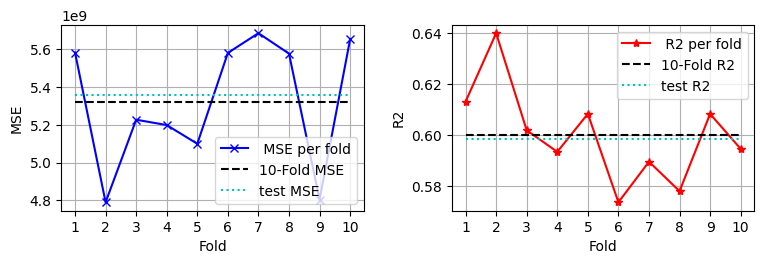

In [31]:
plt.figure(figsize=(8, 3))

plt.subplot(121)
plt.plot( np.arange( 1, 1+len(mse_kfold)  ), mse_kfold, 'bx-' , label=' MSE per fold' )
plt.plot([1, 10 ], [mse_mean, mse_mean ], 'k--', label='10-Fold MSE' )
plt.plot([1, 10 ], [test_mse, test_mse ], 'c:' , label='test MSE')
plt.xticks(np.arange(1,11) )
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.grid()
plt.legend()


plt.subplot(122)
plt.plot(  np.arange( 1, 1+len(mse_kfold)  ), r2_kfold, 'r*-' , label=' R2 per fold')
plt.plot([1, 10 ], [mse_r2, mse_r2 ] , 'k--' , label='10-Fold R2' )
plt.plot([1, 10 ], [test_r2, test_r2 ], 'c:' , label='test R2')
plt.xticks(np.arange(1,11) )
plt.xlabel('Fold')
plt.ylabel('R2')
plt.grid()
plt.legend()

plt.tight_layout(pad=2)  # Increase the spacing between subplots
plt.show()

**[5pts]** Provide intepretation to the plot. How does the test do compared to the estimation given by the CV validation.

The 10-fold CV results are very close to the test results. The CV estimate is a good prediction on of how the model performs on unseen data. But the test R-squared is lower while the test MSE is higher, which means the model performs a little poorly on the test set than estimated by CV.

## Gradient descendent


In this part, we are going to write batch gradient descendent. We also will include regularization parameters to train our regression model.

The cost function for the elastic net is defined as:

$ J(b) = \sum_{i=1}^{N} (y_i - X_ib)^2  + \lambda ( \frac{1-\alpha}{2} ||b||_2^2 + \alpha |b| ) $

$ J(b) = \sum_{i=1}^{N} (y_i - X_ib)^2  + \lambda \frac{1-\alpha}{2} ||b||_2^2 +  \lambda \alpha |b|  $

This function can be analyzed as the addition of three functions as:

$f(b)= \sum_{i=1}^{N} (y_i - X_ib)^2 $

$g(b)= \lambda \frac{1-\alpha}{2} ||b||_2^2  $

$z(b)= \lambda \alpha |b| $

so, $ J(b) = f(b) + g(b) + z(b) $


Also, remember that the derivative of the addition of a function is equal to the addition of its derivates. Namely:

$ \frac{\partial J(b) }{ \partial b } =  \frac{\partial f(b) }{ \partial b } + \frac{\partial g(b) }{ \partial b } + \frac{\partial z(b) }{\partial b } $


In class, we reviewed that $ \frac{\partial f(b) }{ \partial b }= -2X^T(y-Xb)$, so what is missing is the derivates for $g(b)$ and $z(b)$.


$g(b) = \lambda \frac{1-\alpha}{2} ||b||_2^2 = \lambda \frac{1-\alpha}{2} (b_0^2 + b_1^2 + ... + b_p^2) $, asumming we have $p$ predictor variables.

$\frac{  \partial [\lambda \frac{1-\alpha}{2} (b_0^2 + b_1^2 + ... + b_p^2) ] }{ \partial b_i }=\lambda(1-\alpha)b_i$


Likewise,

$z(b) = \lambda \alpha |b| = \lambda \alpha  (|b_0| + |b_1| + ... + |b_p|) $, asumming we have $p$ predictor variables.

$\frac{\partial [\lambda \alpha (|b_0| + |b_1| + ... + |b_i| + |b_p|)]}{\partial b_i} = 
\begin{cases}
-\lambda \alpha, & \text{for } b_i < 0 \\
\lambda \alpha, & \text{for } b_i \geq 0
\end{cases} $



**[8 pts]** Write a function that calculates the gradient for elastic net regularization.

Hint: For the l1 gradient, you may want to use the np.sign(array) that returns 1 for the positive entries and -1 for the negative ones. 

In [32]:
# TO DO

def grad(X_in, y_in, b_in, alpha, lambda_value ):
    #note: for the l1 and l2, after calculating the gradiante, make the first entry 0
    # l2_grad[0]=0 and l1_grad[0]=0. The reason is that regularization is not applied to the intercept
    N = X_in.shape[0]
    
    y_pred = X_in @ b_in
    
    residuals = y_pred - y_in.reshape(-1, 1)
    
    grad_f = (2 / N) * X_in.T @ residuals
    
    # L2 gradient
    grad_g = lambda_value * (1 - alpha) * b_in
    grad_g[0] = 0   # do not regularize intercept
    
    # L1 gradient
    grad_z = lambda_value * alpha * np.sign(b_in)
    grad_z[0] = 0   # do not regularize intercept
    
    g = grad_f + grad_g + grad_z
    
    return g


We will write now a function to calculate the batch gradient descedent algorithm.

**[5 pts]** Complete the function to compute the batch gradient descendent optimization

In [33]:
def batch_gradient_descendent(X_train_in, y_train_in,  alpha, lambda_value, eta=1e-4):
    stop = False
    counter = 0
    totalSamples = X_train_in.shape[0]
    b_s = np.random.RandomState(counter).rand(X_train_in.shape[1], 1)

    rList = []
    iterations = 200

    batch_size = 128

    totalSteps = int((totalSamples - batch_size) / batch_size) + 1

    while not stop:
        idx_shuffle = np.random.RandomState(counter).permutation(totalSamples)
        X_train_iter = X_train_in[idx_shuffle]
        y_train_iter = y_train_in[idx_shuffle]

        learningRate = eta / np.sqrt(counter + 1)

        for currStep in range(totalSteps):

            idxStart = currStep * batch_size
            idxEnd = idxStart + batch_size

            # Select the samples for the current batch
            samples = X_train_iter[idxStart:idxEnd]

            # TO DO #####################
            #update parameters
            g = grad(samples, y_train_iter[idxStart:idxEnd], b_s, alpha, lambda_value)
            b_s = b_s - learningRate * g
            #################################

        counter += 1
        if counter == iterations:
            stop = True

    return b_s

For the remaining part, we are going to convert the pandas structures to numpy arrays to facilitate the computations.

In [34]:
X_train_2 = X_train_dummies.to_numpy()
y_train_2 = y_train.to_numpy()

X_test_2 = X_test_dummies.to_numpy()
y_test_2 = y_test.to_numpy()


print( X_train_2.shape, y_train_2.shape )
print( X_test_2.shape, y_test_2.shape )

(14448, 8) (14448,)
(6192, 8) (6192,)


The function below, normalized and extend the training and test set given as input.

In [35]:
def processingSet( X_train_in, X_test_in ):
    
    # normalizing
    train_mean = np.mean( X_train_in, axis = 0 )
    train_std = np.std( X_train_in, axis = 0 )

    X_train_in = (X_train_in -train_mean )/(train_std )
    X_test_in = (X_test_in -train_mean )/(train_std )

    ## extending 
    X_train_processed =  np.hstack( [np.ones( [X_train_in.shape[0] ,1]), X_train_in ])
    X_test_processed = np.hstack( [np.ones( [X_test_in.shape[0] ,1]), X_test_in ])
    
    #print( np.mean( X_train_processed, axis = 0 ) )
    #print( np.std( X_train_processed, axis = 0 ) )
    return X_train_processed, X_test_processed

**[8 pts]** Complete the code below to perform 2 fold cross validation on the alpha and lamda values. For each pair, the function `batch_gradient_descendent` need to be call. Using return `beta` you need to calculate the prediction for the `X_val` and calcuate the MSE. Use `from sklearn.metrics import mean_squared_error` to compute the mean squared error.

In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error

alphas = [ 0, .1 , .3, .5,  .7,  .9, 1]
lambdas = [ 0.001, 0.01, 0.1, 1, 10, 100  ]

MSE = np.empty( [ len( alphas ), len( lambdas ) ] )
folds = 2
for iAlpha in range( len( alphas ) ):
    for iLambda in range( len( lambdas ) ):
        
       
        # perform k Fold
        skf = StratifiedKFold(n_splits=folds, random_state= 0, shuffle=True )
        mse_kfold = np.empty( folds ) 

        for i, (train_index, val_index) in enumerate(skf.split(X_train_2, income_cat_train )):
            X_train_val, X_val = X_train_2[ train_index ], X_train_2[ val_index ]
            y_train_val, y_val = y_train_2[ train_index ], y_train_2[ val_index ]
            
            
            X_train_val, X_val = processingSet( X_train_val, X_val )
            
            ###### TO DO  #####
            b_opt = batch_gradient_descendent(X_train_val, y_train_val,  alphas[iAlpha], lambdas[iLambda])
            y_pred = X_val @ b_opt
            
            mse_kfold[i] = mean_squared_error(y_val, y_pred)
        
        
   
            #################################################
            
        
        MSE[ iAlpha, iLambda ] =  np.mean( mse_kfold )
        print('alpha:{} lambda:{}, MSE:{}'.format(alphas[iAlpha], lambdas[iLambda], MSE[ iAlpha, iLambda ] ) )    
MSE              

alpha:0 lambda:0.001, MSE:32365644740.36035
alpha:0 lambda:0.01, MSE:32367818042.795692
alpha:0 lambda:0.1, MSE:32389486086.498318
alpha:0 lambda:1, MSE:32599686168.4455
alpha:0 lambda:10, MSE:34128224448.279823
alpha:0 lambda:100, MSE:36306391264.649765
alpha:0.1 lambda:0.001, MSE:32365620589.19811
alpha:0.1 lambda:0.01, MSE:32367576655.889378
alpha:0.1 lambda:0.1, MSE:32387084687.025124
alpha:0.1 lambda:1, MSE:32576913505.14853
alpha:0.1 lambda:10, MSE:34002046364.173897
alpha:0.1 lambda:100, MSE:36262834778.30708
alpha:0.3 lambda:0.001, MSE:32365572286.436108
alpha:0.3 lambda:0.01, MSE:32367093838.31997
alpha:0.3 lambda:0.1, MSE:32382277513.66655
alpha:0.3 lambda:1, MSE:32530934808.424225
alpha:0.3 lambda:10, MSE:33721204429.908653
alpha:0.3 lambda:100, MSE:36140565412.388885
alpha:0.5 lambda:0.001, MSE:32365523983.09066
alpha:0.5 lambda:0.01, MSE:32366610962.408203
alpha:0.5 lambda:0.1, MSE:32377464507.34163
alpha:0.5 lambda:1, MSE:32484376615.327095
alpha:0.5 lambda:10, MSE:333976

array([[3.23656447e+10, 3.23678180e+10, 3.23894861e+10, 3.25996862e+10,
        3.41282244e+10, 3.63063913e+10],
       [3.23656206e+10, 3.23675767e+10, 3.23870847e+10, 3.25769135e+10,
        3.40020464e+10, 3.62628348e+10],
       [3.23655723e+10, 3.23670938e+10, 3.23822775e+10, 3.25309348e+10,
        3.37212044e+10, 3.61405654e+10],
       [3.23655240e+10, 3.23666110e+10, 3.23774645e+10, 3.24843766e+10,
        3.33976657e+10, 3.59285205e+10],
       [3.23654757e+10, 3.23661280e+10, 3.23726457e+10, 3.24372373e+10,
        3.30256785e+10, 3.54773419e+10],
       [3.23654274e+10, 3.23656450e+10, 3.23678210e+10, 3.23895155e+10,
        3.25999727e+10, 3.41302751e+10],
       [3.23654032e+10, 3.23654035e+10, 3.23654065e+10, 3.23654360e+10,
        3.23657312e+10, 3.23686848e+10]])

this is the picture, so that you can check your solution

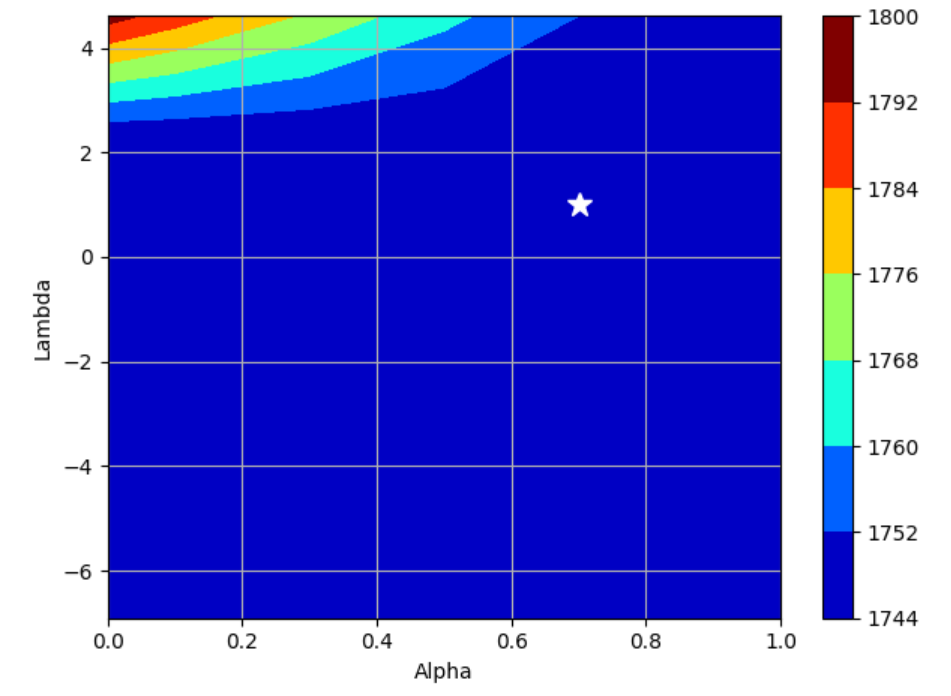

In [37]:
MSE_best_lambda =  np.min( MSE, axis=1)
best_alpha_idx = np.argmin( MSE_best_lambda )

best_lambda_idx = np.argmin( MSE[best_alpha_idx,:] )

minMSE = MSE[ best_alpha_idx, best_lambda_idx ]
bestAlpha = alphas[best_alpha_idx]
bestLambda = lambdas[  best_lambda_idx ]

minMSE, np.min( MSE) , bestAlpha, bestLambda

(np.float64(32365403222.174583), np.float64(32365403222.174583), 1, 0.001)

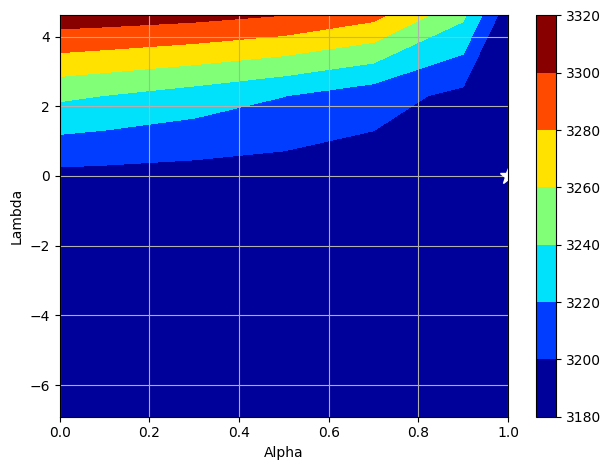

In [38]:
X_grid, Y_grid = np.meshgrid( np.log(lambdas), alphas   )
Z_grid =  np.cbrt(MSE )


plt.figure()
plt.contourf(  Y_grid, X_grid, Z_grid , cmap = 'jet', vmin= np.nanmin( Z_grid) , vmax= np.nanmax( Z_grid) )
plt.plot(   alphas[best_alpha_idx], lambdas[  best_lambda_idx ],'w*', markersize=12 )
plt.axis([ np.nanmin(Y_grid), np.nanmax(Y_grid), np.nanmin(X_grid), np.nanmax(X_grid) ])
plt.xlabel("Alpha")
plt.ylabel("Lambda")

plt.grid()
plt.colorbar()
plt.tight_layout()
#plt.savefig( 'plot3.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

**[4 pts]** Provide interpretation for the figure above. Which type of regularization is better for our training data?

The lowest error appears in the dark blue regon, this happens when lambda is nagative and the alpha is small. An increase in the lambda (positive and larger), will increase the error. Using Ridge regularization will be better for training our data because it gives a lower error value.

Let's process the data for test.

In [39]:
X_train_extended, X_test_extended = processingSet( X_train_2, X_test_2 )

We recalculate the beta using now all the training data.

In [40]:
b_s = batch_gradient_descendent( X_train_extended, y_train_2, bestAlpha, bestLambda   )
b_s

array([[ 93451.76201979],
       [ -4780.2819624 ],
       [  5643.71499677],
       [  6015.96372352],
       [ 34102.95199872],
       [  1186.91403986],
       [  6796.693074  ],
       [  5347.18227326],
       [-21207.63434602]])

We also calculate the LSE, to compare our beta given by the batch normalization

In [41]:
beta_lse = np.linalg.inv( X_train_extended.T @ X_train_extended) @X_train_extended.T@y_train_2

In [42]:
np.linalg.norm(b_s - beta_lse)

np.float64(683507.7934824129)

**[3 pts]** Calculate the prediction for the test set using the vector `b_s`

In [43]:
yHat_s = X_test_extended @ b_s

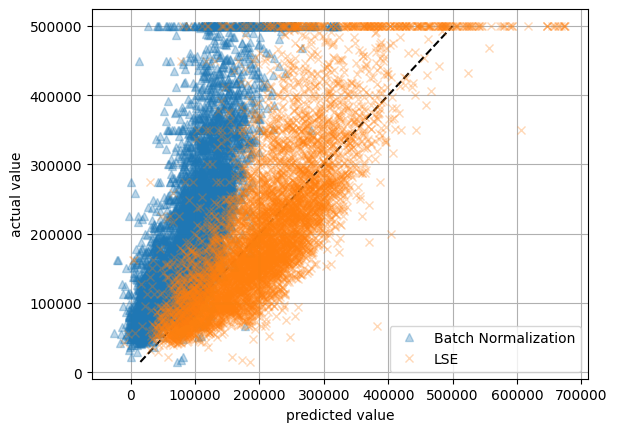

In [44]:
yHat_lse = X_test_extended @ beta_lse


plt.figure( )
plt.plot( [np.min(y_test_2), np.max(y_test_2) ], [ np.min(y_test_2), np.max(y_test_2) ] , '--k') # reference line
plt.plot(yHat_s, y_test_2, '^' , alpha=.3, label= 'Batch Normalization')
plt.plot(yHat_lse, y_test_2, 'x' , alpha=.3, label='LSE')
plt.xlabel( 'predicted value')
plt.ylabel( 'actual value')
plt.legend()
plt.grid()
plt.show()

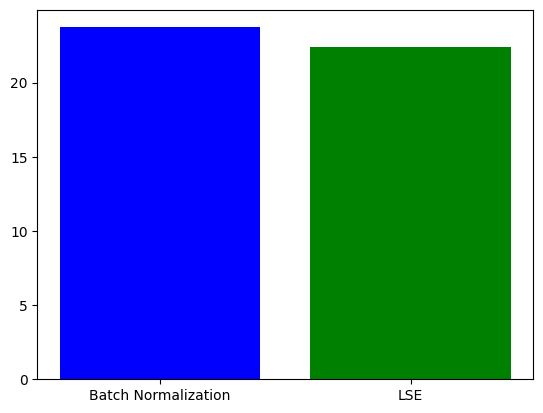

In [45]:
MSE_s = np.mean( (y_test_2- np.squeeze( yHat_s ))**2 )
MSE_lse = np.mean( (y_test_2 - yHat_lse)**2 )

plt.plot()
bars = plt.bar(['Batch Normalization', 'LSE'], [ np.log(MSE_s), np.log(MSE_lse)], color=['blue', 'green'])


**[4 pts]** How did the batch normalization do in comparison to the Least Square Errors?

The batch normalization performs better than the LSE because overall it obtained a higher value on the graph. This means the model which used batch normalization achieved slightly better performance than the model which used LSE. 